# Fig. 5, Extended Fig. 6: Tracking individual cells across days

1. To identify cells tracked across days, first run Run_ROI_Aligner.ipynb.  \
    a. you may need to separate the sess class for each session into its own file,  \
    and put it in a directory per animal, or edit the code to accomodate your preferred directory structure. \
    b. Save the results of the aligner as 'roi_aligner_results.pkl' in a directory per animal \
    (this is how it's called in multiDayROIAlign).
    
2. Once you have these alignment results, you can run this notebook.

### Table of Contents

[Load multiDayData, where cells have already been classified by remapping type](#Load-pre-saved-multiDayData)  \
[Match cells from one switch day to the next by remapping category](#Main-loop-to-match-cells-by-remapping-type)  \
[LMMs on cell fractions tracked](#LMMs-on-cell-fractions-tracked)  \
[Sequences tracked across days](#Sequences-tracked-across-days)


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import dill
import numpy as np
import scipy as sp
import pandas as pd
import warnings
from tqdm import tqdm
import copy
import astropy
from astropy import stats
import phase_precession.core as ppcore
from datetime import datetime

from matplotlib import pyplot as plt
from matplotlib import cm
import statsmodels.formula.api as smf
import seaborn as sns
sns.set_style("white")

from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import multiDayROIAlign as roiAlign
from reward_relative import circ

save_figures = False

In [2]:
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [3]:
path_dict

{'preprocessed_root': '/data/2p_data',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2p_data/VR_Data',
 'git_repo_root': '/home/sosalab/local_repos',
 'TwoPUtils': '/home/sosalab/local_repos/TwoPUtils',
 'home': '/home/sosalab',
 'fig_dir': '/data/2p_data/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2p_data/fig_scratch/Mar2026


## Load pre-saved multiDayData

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year='combined')
ts_key = 'dff'  # used to find place field peaks

dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multi_anim_sess', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"))

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']

/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


# Main loop to match cells by remapping type

[Back to table of contents](#Table-of-Contents)

In [6]:
def get_tracked_data(_cell_ids, _multiDayData, _day, _an, _cat):
    
    # find tracked target cells that are also place cells/included in the targ data set
    in_ = ut.lookup_ind_exact(_cell_ids,
                                          np.where(_multiDayData[_day].overall_place_cell_masks[_an])[0]) 
                                              
    # initialize
    id_ = np.zeros(in_.shape)*np.nan
    dist_ = np.zeros(in_.shape)*np.nan

    along_unity_ = np.zeros(in_.shape)*np.nan
    peaks_ = {'set 0': np.zeros(in_.shape)*np.nan,
                  'set 1': np.zeros(in_.shape)*np.nan,
                 }
    rel_peaks_ = {'set 0': np.zeros(in_.shape)*np.nan,
                  'set 1': np.zeros(in_.shape)*np.nan,
                 }
    
    # assign data
    in_kept = np.where(_multiDayData[_day].overall_place_cell_masks[an])[0][
        in_[~np.isnan(in_)].astype(int)]
    id_[~np.isnan(in_)] = in_kept
    
    # rel peak locations
    rel_peaks_['set 0'][~np.isnan(in_)] = _multiDayData[_day].rel_peaks[_an]['set 0'][
        in_[~np.isnan(in_)].astype(int)]
    rel_peaks_['set 1'][~np.isnan(in_)] = _multiDayData[_day].rel_peaks[_an]['set 1'][
        in_[~np.isnan(in_)].astype(int)]
    
    dist_[~np.isnan(in_)] = circ.phase_diff(rel_peaks_['set 0'][~np.isnan(in_)],
                                            rel_peaks_['set 1'][~np.isnan(in_)]
                                           ) # dist_btwn_rel_peaks

    # only accepting peaks of cells that were accepted place cells on this day
    peaks_['set 0'][~np.isnan(in_)] = _multiDayData[_day].peaks[_an]['set 0'][in_kept]
    peaks_['set 1'][~np.isnan(in_)] = _multiDayData[_day].peaks[_an]['set 1'][in_kept]  
    
    out = {'id': id_, # ids of the tracked cells that were also pcs
           'dist': dist_,
           'peaks': peaks_,
           'rel_peaks': rel_peaks_,
          }
    
    return out

In [ ]:
## Main loop

# get session metadata
from reward_relative.sessions_dict import single_plane, multi_plane
all_sess = single_plane
all_sess.update(multi_plane)

anim_list = max_anim_list

n_cells = []
tracked = dict(
    [(an, {'day_combo': {},
           'n_tracked': {},
           'n_ref': {},
           'frac_tracked': {},
           }) for an in anim_list]
)

# 50 cm converted to radians
rdist_to_rad_inc = multiDayData[exp_days[0]
                                ].circ_rel_stats_across_an['rdist_to_rad_inc']

cats = ['rr', 'pc', 'track', 'nontrack_pc', 'appear',
        'disappear', 'nonreward_remap', 'nonpc']

for an in anim_list:
    [tracked[an].update({cat: {}}) for cat in cats]

# option to limit to cells with sig. SI before AND after the switch
limit_rr_to_and = False

df = pd.DataFrame(columns=['mouse',
                           'combo_len',
                           'day_combo',
                           'n_tracked',
                           'n_ref',
                           'frac_tracked',
                           'frac_rr_becoming_rr', #i.e. "staying" rr
                           'frac_pc_becoming_rr',
                           'frac_nonpc_becoming_rr'])

align_days = [3, 5, 7, 8, 10, 12, 14] 
n = 2  # to align across groups of 2 switch days

# Iterate through each combo of 2 consecutive switch days
day_slices = ut.subsequences(align_days, n)

for ds_i, ds in enumerate(day_slices):
    print(ds_i, ds)
    common_rois = roiAlign.find_common_rois(anim_list, ds)
    ref_day = ds[0]
    targ_day = ds[1]

    for an in common_rois.keys():

        tracked[an]['day_combo'] = np.zeros((len(day_slices), n))
        tracked[an]['n_tracked'] = np.zeros((len(day_slices), 1))
        tracked[an]['n_ref'] = np.zeros((len(day_slices), 1))
        tracked[an]['frac_tracked'] = np.zeros((len(day_slices), 1))

        day_ind = ut.get_ind_of_exp_day(all_sess, an, ref_day)

        # Iterate through categories and find which cells were tracked across days
        for cat in cats:
            # ['rr','pc','track','appear','disappear','nonreward_remap','nonpc']

            # IMPORTANT: do 'rr' first, as it will get excluded from all other categories
            if cat == 'rr':
                # reward relative cells
                ids = np.copy(
                    multiDayData[ref_day].reward_rel_cell_ids[an])
                if limit_rr_to_and:
                    ids = ids[np.isin(ids,
                                      np.where(np.logical_and(
                                          multiDayData[ref_day].place_cell_masks[an]['set 0'],
                                          multiDayData[ref_day].place_cell_masks[an]['set 1']
                                      ))[0])]
                rr_ids = np.copy(ids)
                print('rr cells', len(rr_ids))
            elif cat == 'pc': #place cells
                # find the pcs that are not rr cells on the ref day
                # do this by place cell masks
                ids = np.where(np.logical_or(
                    multiDayData[ref_day].place_cell_masks[an]['set 0'],
                    multiDayData[ref_day].place_cell_masks[an]['set 1']
                ))[0]
                # exclude reward-relative cells
                ids = ids[~np.isin(ids, rr_ids
                                   )]
            elif cat == 'nontrack_pc':
                # find the pcs that are not rr cells AND not track-relative on the ref day
                # do this by place cell masks, not "keep" (since that could exclude certain cell types)
                ids = np.where(np.logical_or(
                    multiDayData[ref_day].place_cell_masks[an]['set 0'],
                    multiDayData[ref_day].place_cell_masks[an]['set 1']
                ))[0]
                ids = ids[~np.isin(ids, rr_ids
                                   )]
                ids = ids[~np.isin(ids, np.where(
                    multiDayData[ref_day].cell_class[an]['masks']['track'])[0])]

            elif cat in ['track', 'appear', 'disappear']:
                # find cells that were track-relative, appearing, or disappearing
                ids = np.where(
                    multiDayData[ref_day].cell_class[an]['masks'][cat])[0]
                ids = ids[~np.isin(ids, rr_ids
                                   )]
            elif cat == 'nonreward_remap':
                # specifically nonreward remapping cells that are not reward-relative
                ids = np.where(
                    multiDayData[ref_day].cell_class[an]['masks'][cat])[0]
                # print('frac rr cells out of nonreward_remap:',
                #       np.sum(np.isin(
                #           rr_ids,
                #       ids)) / len(ids)
                #      )
                ids = ids[~np.isin(ids, rr_ids
                                   )]
            elif cat == 'nonpc':
                # non place cells on the ref day (in either set of trials)
                ids = np.where(np.logical_and(
                    ~multiDayData[ref_day].place_cell_masks[an]['set 0'],
                    ~multiDayData[ref_day].place_cell_masks[an]['set 1']
                ))[0]

            tracked[an][cat][ds_i] = {}
            tracked[an][cat][ds_i]['orig_id'] = ids

            # --- REF ---
            # returns index of cell ID in the tracked cell list from the ref day
            find_in_tracked = ut.lookup_ind_exact(ids,
                                                  common_rois[an]['common_rois'][ds.index(ref_day), :])
            # get rid of nans (cells that weren't tracked across this day pair)
            find_in_tracked = find_in_tracked[~np.isnan(
                find_in_tracked)].astype(int)

            # get original cell ID of the tracked cells on the ref day
            ref_id = common_rois[an]['common_rois'][ds.index(
                ref_day), find_in_tracked]

            # Get data for these cells (reward-relative [circ] firing peaks, spatial [linear] firing peaks)
            ref_data = get_tracked_data(
                ref_id, multiDayData, ref_day, an, cat)
            tracked[an][cat][ds_i]['id_ref'] = ref_id
            tracked[an][cat][ds_i]['dist_ref'] = ref_data['dist'] # circ distance between relative peaks, radians
            tracked[an][cat][ds_i]['peaks_ref'] = ref_data['peaks']
            tracked[an][cat][ds_i]['rel_peaks_ref'] = ref_data['rel_peaks']

            # --- TARGET ---
            # get cell ID on the target day
            targ_id = common_rois[an]['common_rois'][ds.index(
                targ_day), find_in_tracked]
            # now find the original IDs of the tracked cells on the target day
            # then get their distances on the target day

            targ_data = get_tracked_data(
                targ_id, multiDayData, targ_day, an, cat)
            tracked[an][cat][ds_i]['id_targ'] = targ_data['id']
            tracked[an][cat][ds_i]['dist_targ'] = targ_data['dist']
            tracked[an][cat][ds_i]['peaks_targ'] = targ_data['peaks']
            tracked[an][cat][ds_i]['rel_peaks_targ'] = targ_data['rel_peaks']

            # find abs(delta) between linear peaks on the target day vs. ref day
            # unsigned linear delta:
            tracked[an][cat][ds_i]['delta_peaks'] = np.abs(
                tracked[an][cat][ds_i]['peaks_targ']['set 0'] -
                tracked[an][cat][ds_i]['peaks_ref']['set 0']
            )

            # unsigned circular delta:
            tracked[an][cat][ds_i]['delta_rel_peaks'] = circ.phase_diff(
                tracked[an][cat][ds_i]['rel_peaks_targ']['set 0'], tracked[an][cat][ds_i]['rel_peaks_ref']['set 0']
            )

            # signed circular delta
            tracked[an][cat][ds_i]['signed_delta_rel_peaks'] = circ.wrap(
                tracked[an][cat][ds_i]['rel_peaks_targ']['set 0'] -
                tracked[an][cat][ds_i]['rel_peaks_ref']['set 0']
            )

            # -- track-relative --
            # find ids of cells in the target day that become track relative
            tracked[an][cat][ds_i]['ids_becoming_track_targ'] = tracked[an][cat][ds_i]['id_targ'][
                np.isin(tracked[an][cat][ds_i]['id_targ'],
                        np.where(
                            multiDayData[targ_day].cell_class[an]['masks']['track'])[0]
                        )
            ].astype(int)

            tmp_find_TR = ut.lookup_ind_exact(tracked[an][cat][ds_i]['ids_becoming_track_targ'],
                                             tracked[an][cat][ds_i]['id_targ']).astype(int)

            # find the original cell IDs of cells tracked from ref to targ and staying track-relative
            tracked[an][cat][ds_i]['ids_becoming_track_ref'] = tracked[an][cat][ds_i]['id_ref'][tmp_find_TR]
            # fraction tracked to the target day that are TR on the target day
            tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
                                                                ) / np.sum(
                ~np.isnan(tracked[an][cat][ds_i]['id_targ'])
            )

            # find fraction of cells in each group that are actually tracked
            tracked[an][cat][ds_i]['frac_tracked'] = np.sum(
                ~np.isnan(tracked[an][cat][ds_i]['id_targ'])) / len(tracked[an][cat][ds_i]['id_ref'])

            # -- reward-relative --
            # find ids of cells in the target day that become/stay reward-relative (RR)
            # lookup in reward rel cell list from target day so we incorporate xcorr criteria
            tracked[an][cat][ds_i]['ids_becoming_rr_targ'] = tracked[an][cat][ds_i]['id_targ'][
                np.isin(tracked[an][cat][ds_i]['id_targ'],
                        multiDayData[targ_day].reward_rel_cell_ids[an])
            ].astype(int)

            # if at least 5 cells were tracked, find the fraction of the ref category that became RR
            if np.sum(~np.isnan(tracked[an][cat][ds_i]['dist_targ'])) >= 5:

                becoming_rr = np.isin(
                    tracked[an][cat][ds_i]['id_targ'], multiDayData[targ_day].reward_rel_cell_ids[an])
                if limit_rr_to_and:
                    tmp_rr_ids = tracked[an][cat][ds_i]['id_targ'][becoming_rr]
                    becoming_rr = np.isin(tmp_rr_ids, np.where(np.logical_and(
                        multiDayData[targ_day].place_cell_masks[an]['set 0'],
                        multiDayData[targ_day].place_cell_masks[an]['set 1']
                    ))[0]
                    )
                    tracked[an][cat][ds_i]['ids_becoming_rr_targ'] = tmp_rr_ids[becoming_rr].astype(
                        int)

                # fraction tracked to the target day that are RR on the target day
                tracked[an][cat][ds_i]['frac_becoming_rr'] = np.sum(becoming_rr) / np.sum(
                    ~np.isnan(tracked[an][cat][ds_i]['id_targ'])
                )

            else:
                tracked[an][cat][ds_i]['frac_becoming_rr'] = np.nan

            # find the original cell IDs of cells tracked from ref to targ and staying RR
            tmp_find_RR = ut.lookup_ind_exact(tracked[an][cat][ds_i]['ids_becoming_rr_targ'],
                                           tracked[an][cat][ds_i]['id_targ']).astype(int)

            tracked[an][cat][ds_i]['ids_becoming_rr_ref'] = tracked[an][cat][ds_i]['id_ref'][tmp_find_RR].astype(
                int)


            if cat == 'rr':
                # of the cells that stay rr, do they keep their dist to reward?m', pkl_name
                # use the dist to reward before the switch for this (more stable)

                # find the original cell IDs of cells tracked from ref to targ and staying RR
                orig_ref_id = tracked[an][cat][ds_i]['ids_becoming_rr_ref']
                orig_targ_id = tracked[an][cat][ds_i]['ids_becoming_rr_targ']

                in_rr_ref = np.isin(
                    np.where(multiDayData[ref_day].overall_place_cell_masks[an])[0], orig_ref_id)
                in_rr_targ = np.isin(
                    np.where(multiDayData[targ_day].overall_place_cell_masks[an])[0], orig_targ_id)

                # just take the relative dist in the before sequence:
                tracked[an][cat][ds_i]['dist_to_rew_ref'] = multiDayData[ref_day].rel_peaks[an]['set 0'][in_rr_ref]
                tracked[an][cat][ds_i]['dist_to_rew_targ'] = multiDayData[targ_day].rel_peaks[an]['set 0'][in_rr_targ]

        # Collect all the data
        tracked[an]['day_combo'][ds_i, :] = ds
        tracked[an]['n_tracked'][ds_i] = common_rois[an]['common_rois'].shape[1]
        tracked[an]['n_ref'][ds_i] = common_rois[an]['n_cells'].astype(
            int)
        tracked[an]['frac_tracked'][ds_i] = tracked[an]['n_tracked'][ds_i] / \
            tracked[an]['n_ref'][ds_i]

        df_this_combo = pd.DataFrame({'mouse': an, 'combo_len': n, 'day_combo_i': ds_i, 'day_combo': [ds],
                                      'n_tracked': common_rois[an]['common_rois'].shape[1],
                                      'n_ref': common_rois[an]['n_cells'].astype(int),
                                      'frac_tracked': tracked[an]['frac_tracked'][ds_i],
                                      })

        for cat in cats:
            df_this_combo[f'frac_{cat}_becoming_rr'] = tracked[an][cat][ds_i]['frac_becoming_rr']
            df_this_combo[f'frac_{cat}_tracked'] = tracked[an][cat][ds_i]['frac_tracked']
            df_this_combo[f'frac_{cat}_becoming_track'] = tracked[an][cat][ds_i]['frac_becoming_track']

        df = pd.concat([df, df_this_combo], ignore_index=True)

0 [3, 5]
multi day ROI align: using firebird path dict


14it [00:00, 24.36it/s]
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
/tmp/ipykernel_1364962/1916146823.py:202: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_tracked'] = np.sum(


rr cells 292
rr cells 65
rr cells 78
rr cells 147
rr cells 64
rr cells 67
rr cells 11
rr cells 119
rr cells 11
rr cells 69
rr cells 112
rr cells 50
rr cells 168
rr cells 29
1 [5, 7]
multi day ROI align: using firebird path dict


14it [00:00, 25.51it/s]
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']


rr cells 319
rr cells 61
rr cells 52
rr cells 138
rr cells 39
rr cells 104
rr cells 11
rr cells 57
rr cells 22
rr cells 92
rr cells 119
rr cells 23
rr cells 202
rr cells 29
2 [7, 8]
multi day ROI align: using firebird path dict


...

rr cells 335
rr cells 56
rr cells 51
rr cells 136
rr cells 98
rr cells 111
rr cells 18
rr cells 133
rr cells 41
rr cells 151
rr cells 162
rr cells 50
rr cells 221
rr cells 41
4 [10, 12]
multi day ROI align: using firebird path dict


14it [00:00, 24.90it/s]
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']


rr cells 312
rr cells 62
rr cells 38
rr cells 215
rr cells 71
rr cells 101
rr cells 14
rr cells 57
rr cells 26
rr cells 111
rr cells 166
rr cells 41
rr cells 214
rr cells 73
5 [12, 14]
multi day ROI align: using firebird path dict


14it [00:00, 25.72it/s]
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
/tmp/ipykernel_1364962/1916146823.py:196: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_becoming_track'] = len(tracked[an][cat][ds_i]['ids_becoming_track_targ']
/tmp/ipykernel_1364962/1916146823.py:202: RuntimeWarning: invalid value encountered in scalar divide
  tracked[an][cat][ds_i]['frac_tracked'] = np.sum(


rr cells 275
rr cells 42
rr cells 34
rr cells 205
rr cells 29
rr cells 132
rr cells 30
rr cells 96
rr cells 28
rr cells 116
rr cells 109
rr cells 29
rr cells 217
rr cells 58


### Plot tracked cell types with ROIs

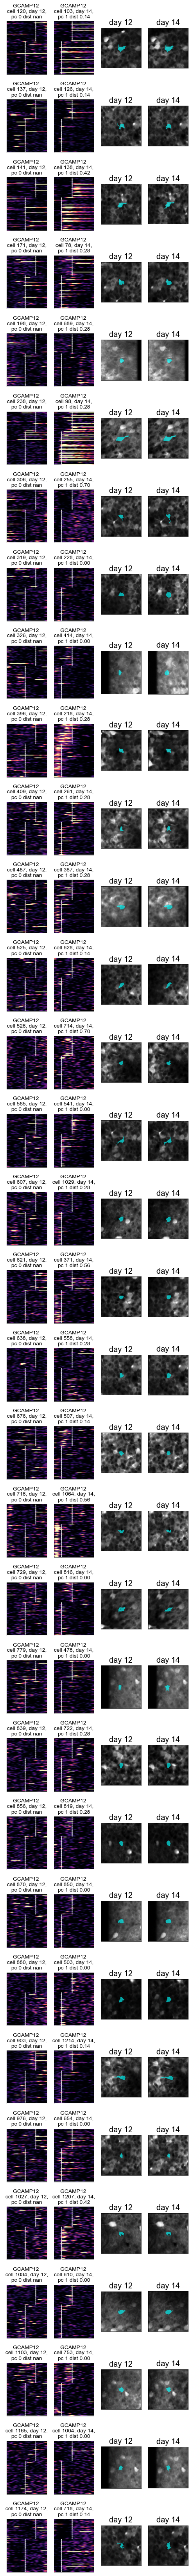

In [10]:
an_list = ['GCAMP12']
ds_i = 5
base_pkl_path = os.path.join(path_dict['preprocessed_root'],"sess")

# cell class on ref day
key = 'nonpc'  # 'rr', 'track', 'pc', 'nonpc', 'appear', 'disappear', 'nontrack_pc'

# what the cell converts into
become_key = 'rr' # 'rr' or 'track'

# for square aspect
aspect = 796/512

for an in an_list:

    roi_match = dill.load(open(os.path.join(base_pkl_path,an,'roi_aligner_results.pkl'), "rb")) 

    
    ref_ids =  tracked[an][key][ds_i][f'ids_becoming_{become_key}_ref']
    targ_ids = tracked[an][key][ds_i][f'ids_becoming_{become_key}_targ']
    nanmask = ~np.isnan(targ_ids)
    
    if nanmask.sum()>0:

        fig, ax = plt.subplots(nanmask.sum(), len(ds)*2, figsize=(len(day_slices[ds_i])*2.5,2*nanmask.sum()),
                              squeeze=False)

        for c_i,cell_ind in enumerate(np.where(nanmask)[0]):

            # normalize trial_matrices across the 2 days:
            cell_id_ref_day = int(ref_ids[cell_ind])
            cell_id_targ_day = int(targ_ids[cell_ind])
            ref_mat = multiDayData[day_slices[ds_i][0]].events[an][:,:,cell_id_ref_day]
            targ_mat = multiDayData[day_slices[ds_i][1]].events[an][:,:,cell_id_targ_day]

            use_norm = np.nanmean(ref_mat.ravel())
            
            norm_ref_mat = ref_mat / use_norm
            norm_targ_mat = targ_mat / use_norm

            for d_i, day in enumerate(day_slices[ds_i]):

                if d_i==0:
                    cell_id_this_day = cell_id_ref_day
                    pf = ut.nansmooth(norm_ref_mat, 1, axis=1)
                    if key == 'nonpc':
                        dist = np.nan
                    else:
                        dist = tracked[an][key][ds_i]['dist_ref'][np.where(
                            tracked[an][key][ds_i]['id_ref']== ref_ids[cell_ind])[0]][0]
                elif d_i==1:
                    cell_id_this_day = cell_id_targ_day #int(targ_ids[cell_ind])
                    pf = ut.nansmooth(norm_targ_mat, 1, axis=1)
                    dist = tracked[an][key][ds_i]['dist_targ'][np.where(
                        tracked[an][key][ds_i]['id_targ']== targ_ids[cell_ind])[0]][0]
                # iou_this_day = common_rois[an]['iou'][days_to_align.index(day),cell_ind]
                is_pc = np.isin(cell_id_this_day, 
                                np.where(multiDayData[day].overall_place_cell_masks[an])[0])

                # Plot the cell trial-by-trial firing pattern each day
                placeCellPlot.plot_single_cell(
                    ax[c_i, d_i],
                    trial_mat=pf,
                    vlim=[0,10],
                    reward_zone=multiDayData[day].rzone_by_trial[an],
                    markersize=1,
                    label_axes=False,
                )

                for j, entry in enumerate(roi_match['sess_deets']):
                    # print(i)
                    if entry["exp_day"] == day:
                        day_ind = j

                sess_deets = roi_match['sess_deets'][day_ind]
                
                # Plot the local FOV
                if not np.isnan(sess_deets['scan']):
                    with open(os.path.join(base_pkl_path, an, sess_deets['date'],
                                           "%s_%.3d_%.3d.pickle" % (sess_deets['scene'], 
                                                                    sess_deets['session'], sess_deets['scan']))
                            , 'rb') as file:
                        sess = dill.load(file)

                        roi_com = [sess.s2p_stats[cell_id_this_day]['ypix'].mean(), 
                                   sess.s2p_stats[cell_id_this_day]['xpix'].mean()]

                        ybounds = [int(max(0,roi_com[0]-40)), int(min(512,roi_com[0]+40))]
                        xbounds = [int(max(0,roi_com[1]-(40*aspect))), int(min(796*sess.n_planes,roi_com[1]+(40*aspect)))]

                        # plot local FOV
                        ax[c_i, d_i+len(day_slices[ds_i])].imshow(
                            sess.s2p_ops['meanImg'][ybounds[0]:ybounds[1],
                                                    xbounds[0]:xbounds[1]],
                            cmap='Greys_r',aspect=aspect, )
                            # vmax=np.percentile(sess.s2p_ops['meanImg'][ybounds[0]:ybounds[1],
                            #                         xbounds[0]:xbounds[1]].ravel(),99.9) ) #'auto')
                        roi = np.zeros([512,796*sess.n_planes])*np.nan
                        roi[sess.s2p_stats[cell_id_this_day]['ypix'], 
                            sess.s2p_stats[cell_id_this_day]['xpix']]=1
                # plot ROI shading
                ax[c_i, d_i+len(day_slices[ds_i])].imshow(
                    roi[ybounds[0]:ybounds[1],
                        xbounds[0]:xbounds[1]],
                    cmap='cool',alpha=.65, aspect=aspect) #bwr_r
                ax[c_i, d_i+len(day_slices[ds_i])].set_title(f"day {day}")
                ax[c_i, d_i+len(day_slices[ds_i])].set_xticks([])
                ax[c_i, d_i+len(day_slices[ds_i])].set_yticks([])

                ax[c_i,d_i].set_title(
                    f"{an} \n cell {cell_id_this_day}, day {day}, \n pc {is_pc*1} dist {dist:.2f} ", fontsize=10)

        fig.patch.set_facecolor("white")

        save_figure = False
        if save_figure:
            pt.savefig(fig, fig_dir, ("%s_expdays%s_TRACKED_CellType-%s_pf_roi_cyan" % (
                an, "-".join([str(d) for d in day_slices[ds_i]]), key)),
                      extension=".pdf")
    else:
        print('no cells of this category and conversion')
        
                        

## LMMs on cell fractions tracked

[Back to table of contents](#Table-of-Contents)

In [11]:
# these are the fixed-condition animals (no reward switch)
control_ans = ['GCAMP2', 'GCAMP6', 'GCAMP10']

In [12]:
# these are the switch task animals
include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']

/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2026/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is sin

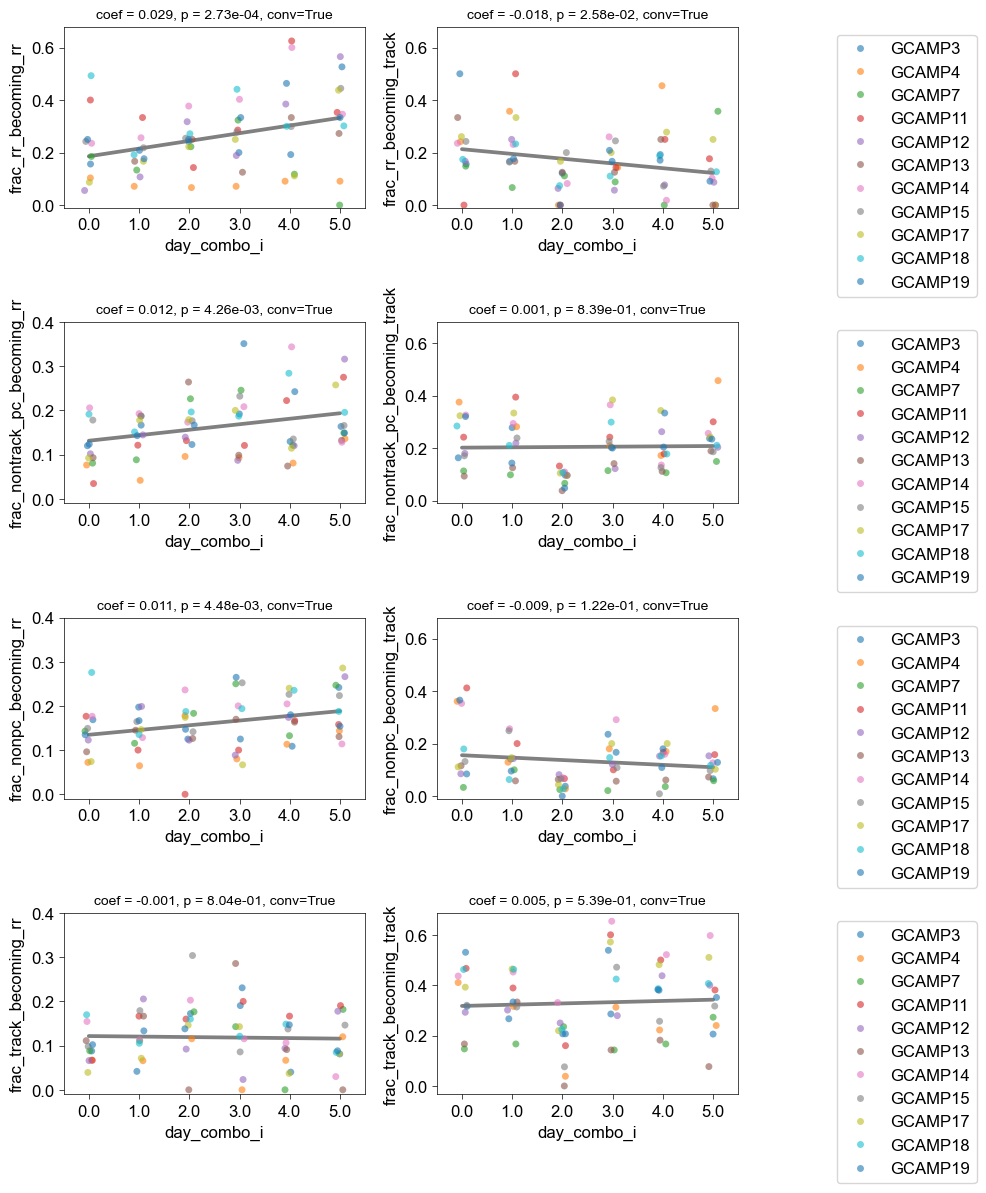

In [13]:
use_ans = include_ans
palette = 'tab10'

# sp.special.expit
_df = df.copy()

cats = ['rr',
        'nontrack_pc',
        'nonpc',
        'track',
        ]

fig, ax = plt.subplots(len(cats), 2, figsize=(10, 3*len(cats)))

# whether to apply a logit transform to all fractions first,
# plus an expit transform of the model fit to plot
logit_transform = False

for cat_i, cat in enumerate(cats):
    
    lmm_rr = smf.mixedlm(f'frac_{cat}_becoming_rr ~ 1 + day_combo_i', groups='mouse', re_formula='~1',
                         data=_df[_df['mouse'].isin(use_ans)], missing='drop').fit(reml=True)

    pt.lmm_plot('day_combo_i', f'frac_{cat}_becoming_rr', df[df['mouse'].isin(use_ans)], 
                ax=ax[cat_i, 0], logit_expit=logit_transform)
    # print('BECOMING RR')
    # print(lmm_rr.summary())
    # print(lmm_rr.wald_test_terms())

    lmm_track = smf.mixedlm(f'frac_{cat}_becoming_track ~ 1 + day_combo_i', groups='mouse', re_formula='~1',
                            data=_df[_df['mouse'].isin(use_ans)], missing='drop').fit(reml=True)

    pt.lmm_plot('day_combo_i', f'frac_{cat}_becoming_track', df[df['mouse'].isin(use_ans)], 
                ax=ax[cat_i, 1], logit_expit=logit_transform, legend_on=True)
    # print('BECOMING TR')
    # print(lmm_track.summary())
    # print(lmm_track.wald_test_terms())

[ax[j, 1].legend(bbox_to_anchor=(1.3, 1)) for j in range(len(ax))]
if logit_transform:
    [ax[j, 1].set_ylim([-0.01, ut.round_up(ax[j, 1].get_ylim()[1], 1)])
     for j in range(len(ax))]
    ax[0, 0].set_ylim([-0.01, 0.65])
    ax[0, 1].set_ylim([-0.01, 0.65])
    [ax[j, 0].set_ylim([-0.01, 0.4]) for j in np.arange(1, len(ax))]
else:
    ax[0, 0].set_ylim([-0.01, 0.68])
    [ax[j, 0].set_ylim([-0.01, 0.4]) for j in np.arange(1,
                                                        len(ax)) if ax[j, 0].get_ylim()[-1] < 0.4]
    [ax[j, 1].set_ylim([-0.01, 0.68]) for j in np.arange(0,
                                                         len(ax)) if ax[j, 1].get_ylim()[-1] < 0.68]

save_figures = False
if save_figures:
    # -rr-restrict-to-and
    if logit_transform:
        pt.savefig(fig, fig_dir, "%s_expday%s_fractions-becoming-rr_%s_%s_%s_wide_%s_logitexpit" % (
            ut.make_anim_tag(use_ans), ut.make_day_tag(
                exp_days), circ_tag, ts_key, place_cell_logical,
            palette)
        )
    else:
        pt.savefig(fig, fig_dir, "%s_expday%s_fractions-becoming-rr_%s_%s_%s_wide_%s" % (
            ut.make_anim_tag(use_ans), ut.make_day_tag(
                exp_days), circ_tag, ts_key, place_cell_logical,
            palette)
        )

In [14]:
df_src = df[['mouse','day_combo','day_combo_i',
             'frac_rr_becoming_rr','frac_nontrack_pc_becoming_rr','frac_nonpc_becoming_rr','frac_track_becoming_rr',
             'frac_rr_becoming_track','frac_nontrack_pc_becoming_track','frac_nonpc_becoming_track','frac_track_becoming_track',
            ]]
df_src
# ut.write_source_csv(df_src, '5b-l')

,mouse,day_combo,day_combo_i,frac_rr_becoming_rr,frac_nontrack_pc_becoming_rr,frac_nonpc_becoming_rr,frac_track_becoming_rr,frac_rr_becoming_track,frac_nontrack_pc_becoming_track,frac_nonpc_becoming_track,frac_track_becoming_track
0,GCAMP2,"[3, 5]",0.0,0.727811,0.606383,0.718750,NaN,0.420118,0.425532,0.281250,0.333333
1,GCAMP3,"[3, 5]",0.0,0.156250,0.123596,0.168675,0.087719,0.156250,0.162921,0.084337,0.315789
2,GCAMP4,"[3, 5]",0.0,0.103448,0.076389,0.072165,0.067164,0.241379,0.375000,0.360825,0.410448
3,GCAMP6,"[3, 5]",0.0,0.476923,0.500000,0.442478,NaN,0.184615,0.155172,0.132743,0.000000
4,GCAMP7,"[3, 5]",0.0,0.185185,0.080645,0.142857,0.088235,0.148148,0.112903,0.032967,0.147059
...,...,...,...,...,...,...,...,...,...,...,...
79,GCAMP14,"[12, 14]",5.0,0.346154,0.128000,0.113924,0.029851,0.102564,0.256000,0.126582,0.597015
80,GCAMP15,"[12, 14]",5.0,0.444444,0.165829,0.223301,0.146341,0.129630,0.185930,0.097087,0.317073
81,GCAMP17,"[12, 14]",5.0,0.437500,0.257576,0.285714,0.081633,0.250000,0.242424,0.102041,0.510204
82,GCAMP18,"[12, 14]",5.0,0.301587,0.195489,0.187500,0.084746,0.126984,0.210526,0.117188,0.406780


## Cross-day stability in firing location (Ext. Fig. 6a-c)

/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)


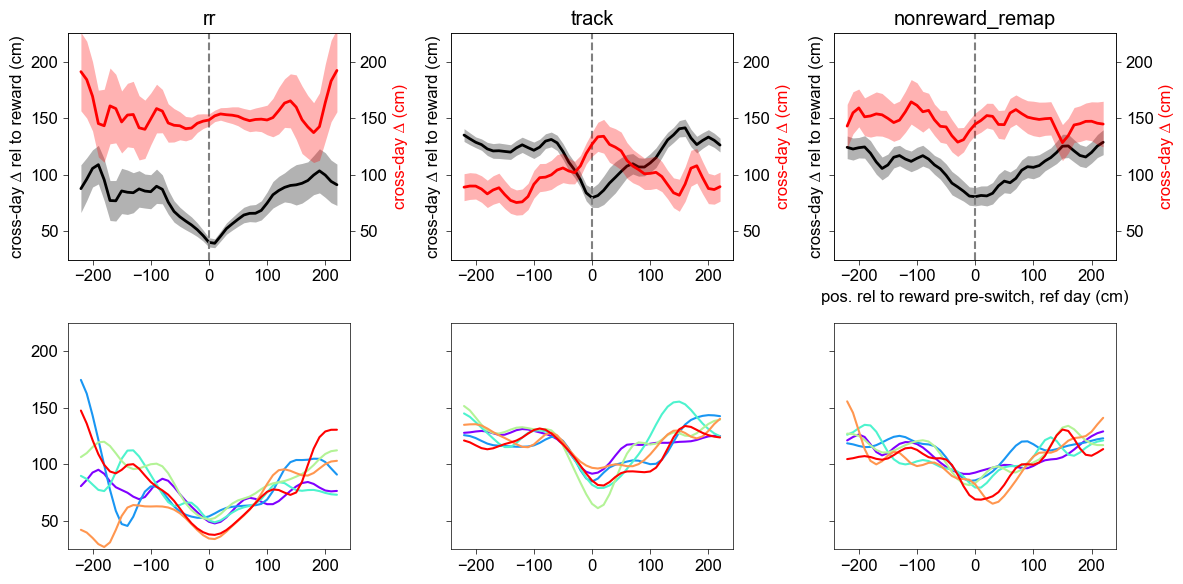

In [15]:
# Relationship between cross-day instability in rr firing peak and original rr field location
colors = cm.rainbow(np.linspace(0, 1, len(day_slices)))
cat_to_plot = ['rr', 'track', 'nonreward_remap']
bin_cm = 10
sm_bin = 2
rel_pos_bins = np.arange(-np.pi, np.pi+spatial.dist_cm_to_rad(bin_cm,
                                                              450, 0), 
                         spatial.dist_cm_to_rad(bin_cm, 450, 0))
rel_pos_bin_centers = rel_pos_bins[:-1] + \
    (spatial.dist_cm_to_rad(bin_cm, 450, 0)/2)

rel_pos_bin_centers = spatial.dist_rad_to_cm(rel_pos_bin_centers)

# "rel peaks" are circular, "peaks" are linear
rel_peaks_ref = dict([(cat, {}) for cat in cat_to_plot])
delta_rel_peaks = dict([(cat, {}) for cat in cat_to_plot])
signed_delta_rel_peaks = dict([(cat, {}) for cat in cat_to_plot])
delta_peaks = dict([(cat, {}) for cat in cat_to_plot])
an_cell_id = dict([(cat, {}) for cat in cat_to_plot])

fig, ax = plt.subplots(2, len(cat_to_plot), figsize=[12, 6], sharey=True)


for cat_i, cat in enumerate(cat_to_plot):
    for ds_i, ds in enumerate(day_slices):

        rel_peaks_ref[cat][ds_i] = np.array([])
        delta_rel_peaks[cat][ds_i] = np.array([])
        signed_delta_rel_peaks[cat][ds_i] = np.array([])

        delta_peaks[cat][ds_i] = np.array([])
        an_cell_id[cat][ds_i] = np.array([])

        for an_i, an in enumerate(include_ans):
            an_cell_id[cat][ds_i] = np.ones(
                (len(tracked[an][cat][ds_i]['rel_peaks_ref']['set 0']), 3))
            an_cell_id[cat][ds_i][:, 0] = an_cell_id[cat][ds_i][:,
                                                                0] * int(ut.get_mouse_number(an))
            an_cell_id[cat][ds_i][:, 1] = tracked[an][cat][ds_i]['id_ref']
            an_cell_id[cat][ds_i][:, 2] = tracked[an][cat][ds_i]['id_targ']

            rel_peaks_ref[cat][ds_i] = np.append(
                rel_peaks_ref[cat][ds_i], tracked[an][cat][ds_i]['rel_peaks_ref']['set 0'])
            delta_rel_peaks[cat][ds_i] = np.append(
                delta_rel_peaks[cat][ds_i], tracked[an][cat][ds_i]['delta_rel_peaks'])
            signed_delta_rel_peaks[cat][ds_i] = np.append(
                signed_delta_rel_peaks[cat][ds_i], tracked[an][cat][ds_i]['signed_delta_rel_peaks'])

            delta_peaks[cat][ds_i] = np.append(
                delta_peaks[cat][ds_i], tracked[an][cat][ds_i]['delta_peaks'])

        # remove nans
        mask = ~np.isnan(delta_rel_peaks[cat][ds_i])
        keep_rel_peaks_ref = rel_peaks_ref[cat][ds_i][mask]
        keep_delta = delta_peaks[cat][ds_i][mask]
        keep_delta_rel = delta_rel_peaks[cat][ds_i][mask]
        keep_signed_delta_rel = signed_delta_rel_peaks[cat][ds_i][mask]

        sorted_ref_peaks = np.sort(keep_rel_peaks_ref)
        sorted_inds = np.argsort(keep_rel_peaks_ref)
        sorted_delta_rel = keep_delta_rel[sorted_inds]
        sorted_delta = keep_delta[sorted_inds]
        # convert delta back to linear cm
        sorted_delta_rel = spatial.dist_rad_to_cm(
            sorted_delta_rel, max_pos=450, min_pos=0)

        delta_rel_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
        delta_rel_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan
        delta_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
        delta_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan

        for b, (edge1, edge2) in enumerate(zip(rel_pos_bins[:-1], rel_pos_bins[1:])):
            find_in_bin = (sorted_ref_peaks > edge1) & (
                sorted_ref_peaks <= edge2)
            if np.where(find_in_bin)[0].shape[0] > 0:
                delta_rel_mean[b] = np.nanmean(sorted_delta_rel[find_in_bin])
                delta_rel_sem[b] = ut.sem(sorted_delta_rel[find_in_bin])
                delta_mean[b] = np.nanmean(sorted_delta[find_in_bin])
                delta_sem[b] = ut.sem(sorted_delta[find_in_bin])

        if sm_bin > 0:
            ax[1, cat_i].plot(rel_pos_bin_centers, ut.nansmooth(
                delta_rel_mean, sm_bin), color=colors[ds_i])

        else:

            ax[1, cat_i].plot(rel_pos_bin_centers,
                               delta_rel_mean, color=colors[ds_i])

    # combine across day pairs and plot overall mean
    combine_rel_peaks = np.concatenate(
        [rel_peaks_ref[cat][ds_i] for ds_i in range(len(day_slices))])
    combine_delta_rel = np.concatenate(
        [delta_rel_peaks[cat][ds_i] for ds_i in range(len(day_slices))])
    combine_signed_delta_rel = np.concatenate(
        [signed_delta_rel_peaks[cat][ds_i] for ds_i in range(len(day_slices))])
    combine_delta = np.concatenate(
        [delta_peaks[cat][ds_i] for ds_i in range(len(day_slices))])
    mask = ~np.isnan(combine_delta_rel)
    keep_rel_peaks_ref = combine_rel_peaks[mask]
    keep_delta = combine_delta[mask]
    keep_delta_rel = combine_delta_rel[mask]
    keep_signed_delta_rel = combine_signed_delta_rel[mask]

    sorted_ref_peaks = np.sort(keep_rel_peaks_ref)
    sorted_inds = np.argsort(keep_rel_peaks_ref)
    sorted_delta_rel = keep_delta_rel[sorted_inds]
    sorted_signed_delta_rel = keep_signed_delta_rel[sorted_inds]

    sorted_delta = keep_delta[sorted_inds]
    # convert delta back to linear cm
    sorted_delta_rel = spatial.dist_rad_to_cm(
        sorted_delta_rel, max_pos=450, min_pos=0)

    delta_rel_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
    delta_rel_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan
    signed_delta_rel_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
    signed_delta_rel_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan
    delta_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
    delta_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan

    # take the mean in each bin
    for b, (edge1, edge2) in enumerate(zip(rel_pos_bins[:-1], rel_pos_bins[1:])):
        find_in_bin = (sorted_ref_peaks > edge1) & (sorted_ref_peaks <= edge2)
        if np.where(find_in_bin)[0].shape[0] > 0:
            delta_rel_mean[b] = np.nanmean(sorted_delta_rel[find_in_bin])
            delta_rel_sem[b] = ut.sem(sorted_delta_rel[find_in_bin])
            signed_delta_rel_mean[b] = np.nanmean(
                sorted_signed_delta_rel[find_in_bin])
            signed_delta_rel_sem[b] = ut.sem(
                sorted_signed_delta_rel[find_in_bin])
            delta_mean[b] = np.nanmean(sorted_delta[find_in_bin])
            delta_sem[b] = ut.sem(sorted_delta[find_in_bin])

    if sm_bin > 0:
        pt.plot_mean_sem(ax[0, cat_i], ut.nansmooth(delta_rel_mean, sm_bin-1),
                         ut.nansmooth(delta_rel_sem, sm_bin-1), xvalues=rel_pos_bin_centers)
    else:
        pt.plot_mean_sem(ax[0, cat_i], delta_rel_mean,
                         delta_rel_sem, xvalues=rel_pos_bin_centers)

    ax[0, cat_i]
    ax[0, cat_i].set_ylabel('cross-day ∆ rel to reward (cm)')
    ax[0, cat_i].set_title(cat)
    ax_right = ax[0, cat_i].twinx()
    ax_right.set_ylim([25, 225])
    if sm_bin > 0:
        pt.plot_mean_sem(ax_right, ut.nansmooth(delta_mean, sm_bin-1),
                         ut.nansmooth(delta_sem, sm_bin-1), xvalues=rel_pos_bin_centers, color='r')
    else:
        pt.plot_mean_sem(ax_right, delta_mean, delta_sem,
                         xvalues=rel_pos_bin_centers, color='r')

    ax_right.set_ylabel('cross-day ∆ (cm)', color='red')

ax[0, cat_i].set_xlabel('pos. rel to reward pre-switch, ref day (cm)')
[ax[0, cat_i].set_ylim([25, 225]) for cat_i in range(len(cat_to_plot))]
[ax[0, cat_i].vlines(0, 25, 225, linestyle='--', color='grey')
 for cat_i in range(len(cat_to_plot))]

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_CrossDayInstability-by-relPos_%s_%s_%s" % (
        ut.make_anim_tag(use_ans), ut.make_day_tag(exp_days), circ_tag, ts_key, place_cell_logical)
    )

/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in scalar divide
  return 

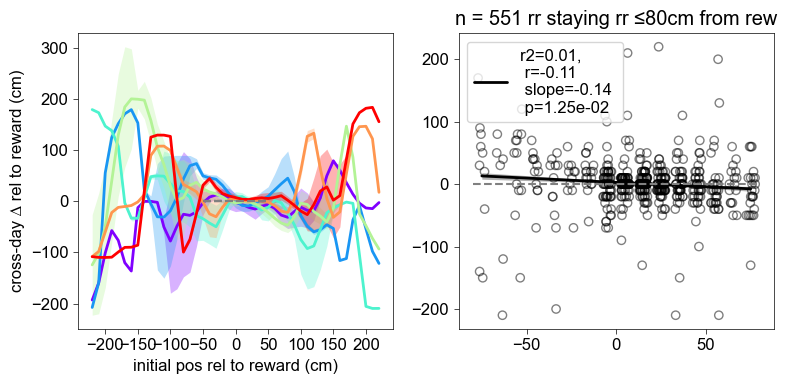

In [ ]:
# plot sequence shape for the cells that remain rr over days
colors = cm.rainbow(np.linspace(0,1,len(day_slices)))

staying_rr_ref_rel_peak = {}
staying_rr_targ_rel_peak = {}
staying_rr_ref_rel_peak_mat = {}
staying_rr_targ_rel_peak_mat = {}
staying_rr_signed_delta = {}
staying_rr_delta = pd.DataFrame(columns=['day_pair','delta'])

rel_pos_bins = np.arange(-np.pi, np.pi+spatial.dist_cm_to_rad(10,450,0), spatial.dist_cm_to_rad(10,450,0))
rel_pos_bin_centers =  rel_pos_bins[:-1] + (spatial.dist_cm_to_rad(10,450,0)/2)

fig2, ax2 = plt.subplots(1,2,figsize=[8,4])

n_anim = np.zeros((len(day_slices),))
    
for ds_i, ds in enumerate(day_slices):

    staying_rr_ref_rel_peak[ds_i] = {'set 0': np.array([]),
                                     'set 1': np.array([])
                                    }
    staying_rr_targ_rel_peak[ds_i] = {'set 0': np.array([]),
                                      'set 1': np.array([])
                                     }
    
    staying_rr_ref_rel_peak_mat[ds_i] = {'set 0': np.zeros((len(include_ans),len(rel_pos_bin_centers))),
                                     'set 1': np.zeros((len(include_ans),len(rel_pos_bin_centers)))
                                    }
    staying_rr_targ_rel_peak_mat[ds_i] = {'set 0': np.zeros((len(include_ans),len(rel_pos_bin_centers))),
                                      'set 1': np.zeros((len(include_ans),len(rel_pos_bin_centers)))
                                     }
    staying_rr_signed_delta[ds_i] = np.array([])
                  
    for an_i, an in enumerate(include_ans):
        
        # get inds of cells that started RR and stayed RR       
        inds_in_ref_data = ut.lookup_ind_exact(
            tracked[an]['rr'][ds_i]['ids_becoming_rr_ref'], 
            tracked[an]['rr'][ds_i]['id_ref']).astype(int)
        inds_in_targ_data = ut.lookup_ind_exact(
            tracked[an]['rr'][ds_i]['ids_becoming_rr_targ'], 
            tracked[an]['rr'][ds_i]['id_targ']).astype(int)
        
        this_delta = tracked[an]['rr'][ds_i]['delta_rel_peaks'][inds_in_targ_data]
        this_signed_delta = tracked[an]['rr'][ds_i]['signed_delta_rel_peaks'][inds_in_ref_data]
        
        this_signed_delta = spatial.dist_rad_to_cm(this_signed_delta, 450, 0)
        
        staying_rr_signed_delta[ds_i] = np.append(staying_rr_signed_delta[ds_i], this_signed_delta)

        staying_rr_delta = pd.concat([staying_rr_delta, pd.DataFrame({'day_pair': np.repeat(ds_i, len(this_delta)),
                                              'delta': this_delta})], ignore_index=True)
        
        this_rel_peaks_ref_set0 = tracked[an]['rr'][ds_i]['rel_peaks_ref']['set 0'][inds_in_ref_data]
        if len(this_rel_peaks_ref_set0) & np.any(np.abs(this_rel_peaks_ref_set0)< spatial.dist_cm_to_rad(80,450,0)):
            n_anim[ds_i] +=1
        this_rel_peaks_ref_set1 = tracked[an]['rr'][ds_i]['rel_peaks_ref']['set 1'][inds_in_ref_data]
        this_rel_peaks_targ_set0 = tracked[an]['rr'][ds_i]['rel_peaks_targ']['set 0'][inds_in_targ_data]
        this_rel_peaks_targ_set1 = tracked[an]['rr'][ds_i]['rel_peaks_targ']['set 1'][inds_in_targ_data]

        staying_rr_ref_rel_peak[ds_i]['set 0'] = np.append(staying_rr_ref_rel_peak[ds_i]['set 0'],
                                                           this_rel_peaks_ref_set0
                                                          )
        staying_rr_ref_rel_peak[ds_i]['set 1'] = np.append(staying_rr_ref_rel_peak[ds_i]['set 1'],
                                                           this_rel_peaks_ref_set1
                                                          )
        
        staying_rr_targ_rel_peak[ds_i]['set 0'] = np.append(staying_rr_targ_rel_peak[ds_i]['set 0'],
                                                           this_rel_peaks_targ_set0
                                                          )
        staying_rr_targ_rel_peak[ds_i]['set 1'] = np.append(staying_rr_targ_rel_peak[ds_i]['set 1'],
                                                           this_rel_peaks_targ_set1
                                                          )
        
        staying_rr_ref_rel_peak_mat[ds_i]['set 0'][an_i,:] = np.histogram(this_rel_peaks_ref_set0, 
                        bins=rel_pos_bins)[0] / np.sum(multiDayData[ds[0]].overall_place_cell_masks[an])
        staying_rr_ref_rel_peak_mat[ds_i]['set 1'][an_i,:] = np.histogram(this_rel_peaks_ref_set1, 
                        bins=rel_pos_bins)[0] / np.sum(multiDayData[ds[0]].overall_place_cell_masks[an])
        staying_rr_targ_rel_peak_mat[ds_i]['set 0'][an_i,:] = np.histogram(this_rel_peaks_targ_set0, 
                        bins=rel_pos_bins)[0] / np.sum(multiDayData[ds[1]].overall_place_cell_masks[an])
        staying_rr_targ_rel_peak_mat[ds_i]['set 1'][an_i,:] = np.histogram(this_rel_peaks_targ_set1, 
                        bins=rel_pos_bins)[0] / np.sum(multiDayData[ds[1]].overall_place_cell_masks[an])
    


    signed_delta_rel_mean = np.zeros((len(rel_pos_bins)-1),)*np.nan
    signed_delta_rel_sem = np.zeros((len(rel_pos_bins)-1),)*np.nan

    for b, (edge1, edge2) in enumerate(zip(rel_pos_bins[:-1], rel_pos_bins[1:])):
        find_in_bin = (staying_rr_ref_rel_peak[ds_i]['set 0'] > edge1
                      ) & (staying_rr_ref_rel_peak[ds_i]['set 0'] <= edge2)
        if np.where(find_in_bin)[0].shape[0] > 0:
            signed_delta_rel_mean[b] = np.nanmean(staying_rr_signed_delta[ds_i][find_in_bin])
            signed_delta_rel_sem[b] = ut.sem(staying_rr_signed_delta[ds_i][find_in_bin])

    if sm_bin>0:
        pt.plot_mean_sem(ax2[0], ut.nansmooth(signed_delta_rel_mean,sm_bin-1), 
                         ut.nansmooth(signed_delta_rel_sem,sm_bin-1), 
                         xvalues=spatial.dist_rad_to_cm(rel_pos_bin_centers, 450,0),
                        color = colors[ds_i,:])
    else:
        pt.plot_mean_sem(ax2[0], signed_delta_rel_mean, 
                         signed_delta_rel_sem, 
                         xvalues=spatial.dist_rad_to_cm(rel_pos_bin_centers, 450,0),
                        color = colors[ds_i,:])
    ax2[0].hlines(0, -50, 50, linestyle='--', color='grey')
    ax2[0].set_xticks(np.arange(-200,250,50))
    
all_staying_rr_ref_rel_peak = np.concatenate(
    [staying_rr_ref_rel_peak[ds_i]['set 0'] 
     for ds_i in range(len(day_slices))])
all_staying_rr_ref_rel_peak = spatial.dist_rad_to_cm(all_staying_rr_ref_rel_peak,450,0)
all_staying_rr_signed_delta = np.concatenate(
    [staying_rr_signed_delta[ds_i] 
     for ds_i in range(len(day_slices))])
near_reward = np.abs(all_staying_rr_ref_rel_peak) <= 80

ax2[-1].scatter(all_staying_rr_ref_rel_peak[near_reward] + (
    np.random.rand(len(all_staying_rr_ref_rel_peak[near_reward]))*5 - 2.5),
               all_staying_rr_signed_delta[near_reward],
               color= 'k',
               alpha=0.5,
                facecolor='none')
pt.plot_lin_reg(all_staying_rr_ref_rel_peak[near_reward], 
                all_staying_rr_signed_delta[near_reward],
                ax2[-1], color = 'k')
# ax2[1+ds_i].set_xlim([-rdist_to_rad_inc, rdist_to_rad_inc])
ax2[-1].hlines(0, -80, 80, linestyle='--', color='grey')
ax2[-1].set_title("n = %d rr staying rr ≤80cm from rew" % (near_reward.sum()))
ax2[0].set_ylabel('cross-day ∆ rel to reward (cm)')
ax2[0].set_xlabel('initial pos rel to reward (cm)')

save_figures = False
if save_figures:
    pt.savefig(fig2, fig_dir, "%s_expday%s_relPos-vs-signedDelta-across-dayPairs_RRstayingRR_%s_%s_%s" % (
            ut.make_anim_tag(use_ans),ut.make_day_tag(exp_days), ts_key, place_cell_logical)
               )

## Sequences tracked across days

[Back to table of contents](#Table-of-Contents)

Re-run the cells below for each of the following options:  \
'rr-to-any_ref1-to-targ0' - RR cells on the ref day that can be anything on the targ day  \
'rr-to-rr_ref1-to-targ0' - RR cells on the ref day that are also RR on the targ day  \
'track_to_any_ref1-to-targ0' - TR cells on the ref day that can be anything on the targ day  \
'track_to_track_ref1-to-targ0' - TR cells on the ref day that are also TR on the targ day

Note we are taking the sequence order from post-switch ref day to pre-switch targ day,  \
as these are the closest in time

In [17]:
# ENTER TYPE OF CELL TO FOLLOW HERE, FROM REF "after" TO TARG "before"
key = 'track'  # remapping category of interest ('rr' or 'track')
to_any = True  # set to True to follow to any category on the targ day, otherwise False to use the same category as key

if to_any:
    follow_tag = f'{key}-to-any_ref1-to-targ0'
else:
    follow_tag = f'{key}-to-{key}_ref1-to-targ0'

# complete options:
# 'rr-to-any_ref1-to-targ0'
# 'rr-to-rr_ref1-to-targ0'
# 'track-to-any_ref1-to-targ0'
# 'track-to-track_ref1-to-targ0'

circ_bin_size = 2*np.pi/(450/10)
tm_bin_edges = np.arange(-np.pi, np.pi + circ_bin_size, circ_bin_size)
tm_bin_centers = tm_bin_edges[:-1] + circ_bin_size / 2

p_thr = 0.05
plot = False  # whether to plot sorted cell sequences

nperms = 1000
rng = np.random.default_rng()

df_seq = df[['mouse', 'day_combo', 'day_combo_i']].copy()

df_seq['cc_rho_ref'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_p_ref'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_rho_targ'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_p_targ'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_rho_reftotarg'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_p_reftotarg'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_rho_reftotarg'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_p_reftotarg'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_rho_reftotarg_perm'] = np.zeros((len(df_seq),))*np.nan
df_seq['cc_p_reftotarg_perm'] = np.zeros((len(df_seq),))*np.nan

cell_n_list = np.zeros((len(day_slices), len(anim_list)))

for ds_i, ds in enumerate(day_slices):
    if plot:
        fig, ax = plt.subplots(len(anim_list), 4, figsize=(8, 15), sharex=True)
    for an_i, an in enumerate(anim_list):

        if an in multiDayData[ds[0]].anim_list:
            cc_rho_perm_reftotarg = np.zeros((nperms,))
            cc_rho_perm_ref = np.zeros((nperms,))
            cc_rho_perm_targ = np.zeros((nperms,))

            if 'any' in follow_tag:
                id_ref = tracked[an][key][ds_i]['id_ref']
                id_targ = tracked[an][key][ds_i]['id_targ']
            else:
                id_ref = tracked[an][key][ds_i][f'ids_becoming_{key}_ref']
                id_targ = tracked[an][key][ds_i][f'ids_becoming_{key}_targ']

            id_ref = id_ref[~np.isnan(id_targ)].astype(int)
            id_targ = id_targ[~np.isnan(id_targ)].astype(int)
            
            # require at least 5 tracked cells to compute a "sequence"
            if len(id_targ) >= 5:

                # normalize each cell's firing rate by the mean FR on the ref day
                norm_per_cell = np.nanmean(
                    np.nanmean(
                        np.vstack([multiDayData[ds[0]].circ_map[an]['set 0'][:, :, id_ref],
                                   multiDayData[ds[0]].circ_map[an]['set 1'][:, :, id_ref]]),
                        axis=0, keepdims=True), axis=1)

                map0_ref = np.nanmean(multiDayData[ds[0]].circ_map[an]['set 0'][:, :, id_ref],
                                      axis=0)
                map1_ref = np.nanmean(multiDayData[ds[0]].circ_map[an]['set 1'][:, :, id_ref],
                                      axis=0)

                map0_targ = np.nanmean(multiDayData[ds[1]].circ_map[an]['set 0'][:, :, id_targ],
                                       axis=0)
                map1_targ = np.nanmean(multiDayData[ds[1]].circ_map[an]['set 1'][:, :, id_targ],
                                       axis=0)

                # sorted based on the pre-switch map on the ref day
                sort0_ref, test_map0_ref, _ = spatial.cross_val_sort(
                    multiDayData[ds[0]].circ_map[an]['set 0'][:, :, id_ref],
                    axis=0)

                sorted_map0_ref = np.nanmean(test_map0_ref, axis=0)
                sorted_map1_ref = map1_ref[:, np.squeeze(sort0_ref)]

                pos0_ref = ut.nanargmax(sorted_map0_ref, axis=0)
                pos1_ref = ut.nanargmax(sorted_map1_ref, axis=0)

                # Calculate circular-circular correlation coefficients within ref day
                cc_rho_ref, cc_pval_ref, _ = ppcore.corr_cc(
                    tm_bin_centers[pos0_ref], tm_bin_centers[pos1_ref])
                for n in range(nperms):
                    perm_ids = rng.permutation(np.arange(map0_ref.shape[1]))
                    sorted_map_ref_perm = map1_ref[:, np.squeeze(
                        perm_ids[sort0_ref])]
                    pos_ref_perm = ut.nanargmax(sorted_map_ref_perm, axis=0)

                    cc_rho_perm_ref[n], _, _ = ppcore.corr_cc(
                        tm_bin_centers[pos0_ref], tm_bin_centers[pos_ref_perm])

                # fill out the dataframe
                mask = (df_seq.mouse.apply(lambda x: an in x) &
                        df_seq.day_combo.apply(lambda x: ds[0] in x) &
                        df_seq.day_combo.apply(lambda x: ds[1] in x))
                df_seq.loc[mask, 'cc_rho_ref'] = cc_rho_ref
                df_seq.loc[mask, 'cc_p_ref'] = ut.permutation_test(
                    cc_rho_perm_ref, cc_rho_ref)  # cc_pval_ref

                # Check the sort within the target day
                sort0_targ, test_map0_targ, _ = spatial.cross_val_sort(
                    multiDayData[ds[1]].circ_map[an]['set 0'][:, :, id_targ],
                    axis=0)

                # np.nanmean(test_map0_targ, axis=0) #map0[:,np.squeeze(sort0)]
                sorted_map0_targ = map0_targ[:, np.squeeze(sort0_ref)]
                sorted_map1_targ = map1_targ[:, np.squeeze(sort0_ref)]

                pos0_targ = ut.nanargmax(
                    sorted_map0_targ, axis=0)  # ut.center_of_mass
                pos1_targ = ut.nanargmax(sorted_map1_targ, axis=0)

                # Calculate circular-circular correlation coefficients within targ day
                cc_rho_targ, cc_pval_targ, _ = ppcore.corr_cc(
                    tm_bin_centers[pos0_targ], tm_bin_centers[pos1_targ])
                for n in range(nperms):
                    perm_ids = rng.permutation(np.arange(map0_targ.shape[1]))
                    sorted_map_targ_perm = map1_targ[:, np.squeeze(
                        perm_ids[sort0_ref])]
                    pos_targ_perm = ut.nanargmax(sorted_map_targ_perm, axis=0)

                    cc_rho_perm_targ[n], _, _ = ppcore.corr_cc(
                        tm_bin_centers[pos0_targ], tm_bin_centers[pos_targ_perm])

                df_seq.loc[mask, 'cc_rho_targ'] = cc_rho_targ
                df_seq.loc[mask, 'cc_p_targ'] = ut.permutation_test(
                    cc_rho_perm_targ, cc_rho_targ)  # cc_pval_targ

                # Calculate circular-circular correlation coefficients from ref to targ day
                cc_rho_reftotarg, cc_pval_reftotarg, _ = ppcore.corr_cc(
                    tm_bin_centers[pos1_ref], tm_bin_centers[pos0_targ])
                df_seq.loc[mask, 'cc_rho_reftotarg'] = cc_rho_reftotarg
                df_seq.loc[mask, 'cc_p_reftotarg'] = cc_pval_reftotarg

                # Get cc corr from permuted cell IDs
                for n in range(nperms):
                    perm_ids = rng.permutation(np.arange(map0_targ.shape[1]))
                    sorted_map_targ_perm = map0_targ[:, np.squeeze(
                        perm_ids[sort0_ref])]
                    pos_targ_perm = ut.nanargmax(sorted_map_targ_perm, axis=0)

                    cc_rho_perm_reftotarg[n], _, _ = ppcore.corr_cc(
                        tm_bin_centers[pos1_ref], tm_bin_centers[pos_targ_perm])

                df_seq.loc[mask, 'cc_rho_reftotarg_perm'] = np.nanpercentile(
                    cc_rho_perm_reftotarg, (1-p_thr)*100) #upper 95th percentile
                df_seq.loc[mask, 'cc_p_reftotarg_perm'] = ut.permutation_test(
                    cc_rho_perm_reftotarg, cc_rho_reftotarg)

                norm_per_cell = norm_per_cell[:, sort0_ref]
                # normalize
                sorted_map0_ref = sorted_map0_ref / norm_per_cell
                sorted_map1_ref = sorted_map1_ref / norm_per_cell
                sorted_map0_targ = sorted_map0_targ / norm_per_cell
                sorted_map1_targ = sorted_map1_targ / norm_per_cell

                cell_n_list[ds_i, an_i] = sorted_map0_ref.shape[-1]

                if plot:
                    # REF
                    ax[an_i, 0].imshow(sorted_map0_ref.T, extent=(-np.pi, np.pi, sorted_map0_ref.shape[-1], 0),
                                       cmap='magma', aspect='auto', vmin=0, vmax=5)
                    ax[an_i, 0].vlines(spatial.pos_cm_to_rad(multiDayData[ds[0]].rzone_pos[an]['set 0'], 450, 0),
                                       sorted_map0_ref.shape[1], 0,
                                       color='w', linestyle=':')
                    h = ax[an_i, 1].imshow(sorted_map1_ref.T, extent=(-np.pi, np.pi, sorted_map0_ref.shape[-1], 0),
                                           cmap='magma', aspect='auto', vmin=0, vmax=5)
                    ax[an_i, 1].vlines(spatial.pos_cm_to_rad(multiDayData[ds[0]].rzone_pos[an]['set 1'], 450, 0),
                                       sorted_map1_ref.shape[1], 0,
                                       color='w', linestyle=':')

                    ax[an_i, 0].set_title("mouse2.%s cc ref r=%.2f pperm=%.3e, \n n=%d" % (
                        ut.get_mouse_number(an), 
                        df_seq.loc[mask, 'cc_rho_ref'], 
                        df_seq.loc[mask, 'cc_p_ref'], 
                        sorted_map0_ref.shape[-1]),
                        fontsize=9)
                    ax[an_i, 0].set_xticks([-3, -2, -1, 0, 1, 2, 3])
                    ax[an_i, 1].set_xticks([-3, -2, -1, 0, 1, 2, 3])
                    ax[an_i, 0].set_ylabel('cells, before-sorted')
                    ax[an_i, 0].set_xlabel('track pos (rad)')

                    # TARGET
                    ax[an_i, 2].imshow(sorted_map0_targ.T, extent=(-np.pi, np.pi, sorted_map0_targ.shape[-1], 0),
                                       cmap='magma', aspect='auto', vmin=0, vmax=5)
                    ax[an_i, 2].vlines(spatial.pos_cm_to_rad(multiDayData[ds[1]].rzone_pos[an]['set 0'], 450, 0),
                                       sorted_map0_targ.shape[1], 0,
                                       color='w', linestyle=':')
                    h = ax[an_i, 3].imshow(sorted_map1_targ.T, extent=(-np.pi, np.pi, sorted_map0_targ.shape[-1], 0),
                                           cmap='magma', aspect='auto', vmin=0, vmax=5)
                    ax[an_i, 3].vlines(spatial.pos_cm_to_rad(multiDayData[ds[1]].rzone_pos[an]['set 1'], 450, 0),
                                       sorted_map1_targ.shape[1], 0,
                                       color='w', linestyle=':')

                    ax[an_i, 2].set_xticks([-3, -2, -1, 0, 1, 2, 3])
                    ax[an_i, 3].set_xticks([-3, -2, -1, 0, 1, 2, 3])

                    ax[an_i, 2].set_title("mouse2.%s cc targ r=%.2f pperm=%.3e \n cc ref to targ r=%.2f pperm=%.3e" % (
                        ut.get_mouse_number(an),
                        df_seq.loc[mask, 'cc_rho_targ'], 
                        df_seq.loc[mask, 'cc_p_targ'],
                        df_seq.loc[mask, 'cc_rho_reftotarg'], 
                        df_seq.loc[mask, 'cc_p_reftotarg_perm']),
                        fontsize=9)

                    fig.suptitle("Day pair %d-%d" % (ds[0], ds[1]))

                    pt.colorbar(h)

    save_figures = False
    if save_figures:
        # -rr-restrict-to-and
        pt.savefig(fig, fig_dir, "%s_daypair%s_tracked-%s_Sequences_ref-vs-targ_%s_%s_%s_xcorrthr_%s" % (
            ut.make_anim_tag(max_anim_list), str(ds), key, circ_tag, ts_key, place_cell_logical, follow_tag), extension='.pdf'
        )

In [18]:
df_seq

,mouse,day_combo,day_combo_i,cc_rho_ref,cc_p_ref,cc_rho_targ,cc_p_targ,cc_rho_reftotarg,cc_p_reftotarg,cc_rho_reftotarg_perm,cc_p_reftotarg_perm
0,GCAMP2,"[3, 5]",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GCAMP3,"[3, 5]",0.0,0.908644,0.000999,-0.124950,0.371628,-0.241473,0.101084,0.226155,0.076923
2,GCAMP4,"[3, 5]",0.0,0.934223,0.000999,0.326226,0.000999,0.273822,0.002774,0.139790,0.002997
3,GCAMP6,"[3, 5]",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GCAMP7,"[3, 5]",0.0,0.895896,0.000999,0.081823,0.649351,-0.017058,0.919530,0.278979,0.927073
...,...,...,...,...,...,...,...,...,...,...,...
79,GCAMP14,"[12, 14]",5.0,0.917719,0.000999,0.272208,0.038961,0.737799,0.000016,0.200998,0.000999
80,GCAMP15,"[12, 14]",5.0,0.866725,0.000999,0.392739,0.011988,0.377656,0.018728,0.272921,0.013986
81,GCAMP17,"[12, 14]",5.0,0.982210,0.000999,0.647014,0.000999,0.657846,0.000002,0.246902,0.000999
82,GCAMP18,"[12, 14]",5.0,0.748698,0.000999,0.052297,0.701299,0.403690,0.005934,0.223719,0.003996


In [19]:
# ut.write_source_csv(df_seq, 'Ext6l')

In [20]:
include_ans = multiDayData[3].circ_rel_stats_across_an['include_ans']

In [21]:
control_ans = ['GCAMP2', 'GCAMP6', 'GCAMP10']

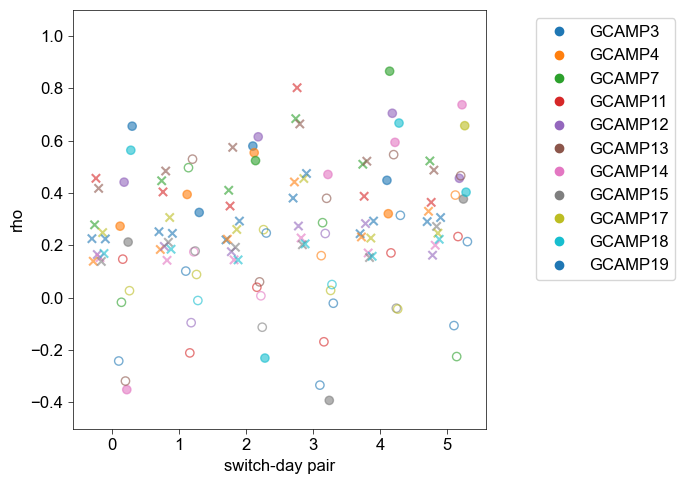

In [22]:
# Plot scatters of rho and 'x' for shuffle upper 95%
fig_q, ax_q = plt.subplots(figsize=(7,5))

## ENTER ANIMAL COHORT TO PLOT HERE
use_ans = include_ans # control_ans OR include_ans
if 'GCAMP2' in use_ans:
    palette = 'dark'
else:
    palette = 'tab10' #'dark' #'tab10'
    
seaborn_palette = sns.color_palette(
    palette, len(use_ans))  # , as_cmap=True)
rgb_tuples = [sns.color_palette(seaborn_palette)[i]
              for i in range(len(seaborn_palette))]
cmap = np.asarray(rgb_tuples)


jitter = np.linspace(-0.1, 0.1, len(use_ans))

for ds_i, ds in enumerate(day_slices):
        
    cc_rhos = df_seq[(df_seq['day_combo_i']==ds_i) & (df_seq['mouse'].isin(use_ans))]['cc_rho_reftotarg']
    cc_rhos_shuf = df_seq[(df_seq['day_combo_i']==ds_i) & (df_seq['mouse'].isin(use_ans))]['cc_rho_reftotarg_perm']
    p_from_shuf = df_seq[(df_seq['day_combo_i']==ds_i) & (df_seq['mouse'].isin(use_ans))]['cc_p_reftotarg_perm']
   
    use_ans = np.array(use_ans)
    cc_rhos = np.asarray(cc_rhos)
    cc_rhos_shuf = np.asarray(cc_rhos_shuf)
    p_from_shuf = np.asarray(p_from_shuf)

    ax_q.scatter(ds_i+jitter[p_from_shuf < p_thr]+0.2, cc_rhos[p_from_shuf <
                                                             p_thr], marker='o', 
                 color=cmap[p_from_shuf < p_thr], alpha=0.6)
    ax_q.scatter(ds_i+jitter[p_from_shuf >= p_thr]+0.2, cc_rhos[p_from_shuf
                                                              >= p_thr], marker='o', 
                 color=cmap[p_from_shuf >= p_thr],
                 facecolor='none', alpha=0.6)
    ax_q.scatter(ds_i+jitter-0.2, cc_rhos_shuf, marker='x',
                 c=cmap, alpha=0.6)

    
    ax_q.set_ylim([-0.5, 1.1])
    ax_q.set_ylabel('rho')
    ax_q.set_xlabel('switch-day pair')
    

# dummy plotting to generate legend because I couldn't figure it out from the scatter
for an_i in range(len(use_ans)):
    ax_q.plot(0, np.nan, 'o', color=cmap[an_i], label=use_ans[an_i])
ax_q.legend(loc="upper left",
            bbox_to_anchor=(1.1, 1))
ax_q.set_xticks(np.arange(len(day_slices)))


save_figures = False
if save_figures:
    #-rr-restrict-to-and
    pt.savefig(fig_q, fig_dir, "%s_expday%s_CorrCC_tracked-%s_SeqRhoReftoTarg_LMM_%s_%s_%s_%s" % (
        ut.make_anim_tag(use_ans),ut.make_day_tag(exp_days), key, circ_tag, ts_key, place_cell_logical, follow_tag)
           )